## Consumer Pricing Analysis

This notebook uses the cleaned PriceCatcher dataset from `data/cleaned`.

### #1 Top 10 items purchased in February 2026

We rank items by transaction count (descending) and visualize the top 10.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

parquet_path = Path("data/cleaned/pricecatcher_modeled_cleaned.parquet")
csv_path = Path("data/cleaned/pricecatcher_modeled_cleaned.csv")

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
elif csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError("No cleaned dataset found in data/cleaned")

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

display(pd.DataFrame([{"rows": len(df), "columns": df.shape[1]}]))
display(df.head())

,rows,columns
0,1032594,15


,date,price,item,unit,item_group,item_category,premise,premise_type,state,district,unit_in_kg,unit_in_liter,price_per_kg,price_per_liter,unit_type
0,2026-02-01,10.6,AYAM BERSIH - SUPER,1kg,BARANGAN SEGAR,AYAM,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,10.6,NaN,mass
1,2026-02-01,14.9,IKAN KELI (ANTARA 2 HINGGA 5 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,IKAN DARAT,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,14.9,NaN,mass
2,2026-02-01,14.2,CILI HIJAU,1kg,BARANGAN SEGAR,SAYUR-SAYURAN,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,14.2,NaN,mass
3,2026-02-01,18.0,CILI MERAH - MINYAK,1kg,BARANGAN SEGAR,SAYUR-SAYURAN,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,18.0,NaN,mass
4,2026-02-01,7.6,HALIA BASAH (TUA),1kg,BARANGAN SEGAR,SAYUR-SAYURAN,JUSCO AYER KEROH,Pasar Raya / Supermarket,Melaka,Melaka Tengah,1.0,NaN,7.6,NaN,mass


,item,transaction_count
0,HALIA BASAH (TUA),22987
1,BAWANG BESAR KUNING/HOLLAND,22850
2,BAWANG PUTIH IMPORT (CHINA),22513
3,LOBAK MERAH,21972
4,TIMUN,21835
5,TOMATO,21373
6,KUBIS BUNGA (CAULIFLOWER),20525
7,UBI KENTANG IMPORT (CHINA),20444
8,KUNYIT HIDUP,19958
9,LENGKUAS,19454


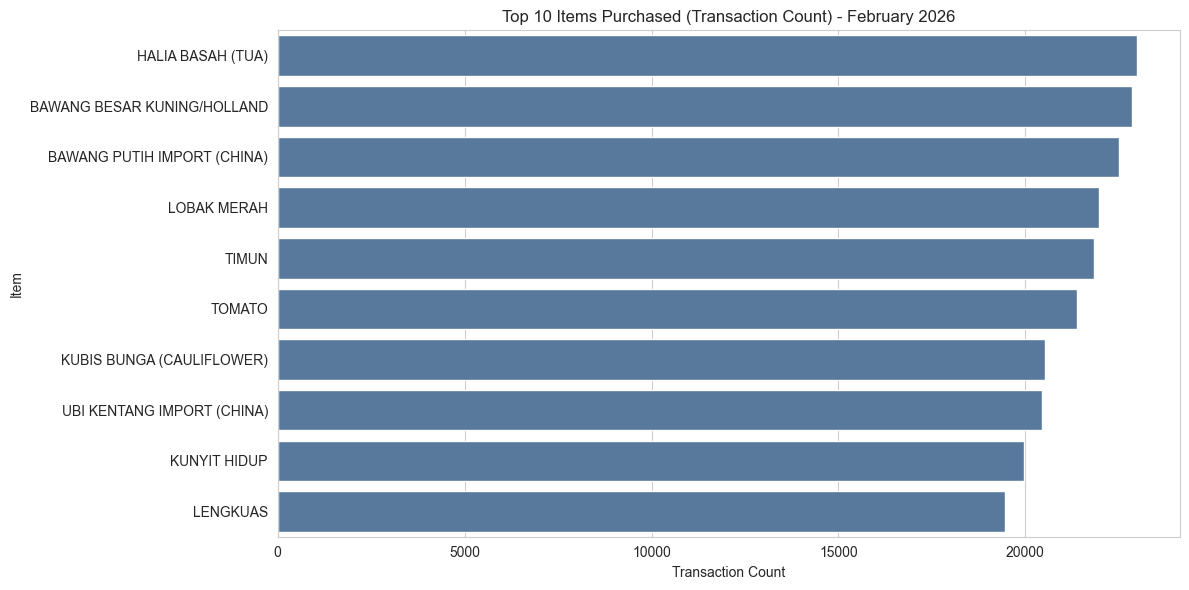

In [ ]:
# Filter to February 2026
feb_2026_df = df.loc[
    (df["date"] >= "2026-02-01") & (df["date"] <= "2026-02-28")
].copy()

# Top 10 items by number of transactions (proxy for purchases)
top_10_items = (
    feb_2026_df["item"]
    .value_counts()
    .head(10)
    .rename_axis("item")
    .reset_index(name="transaction_count")
)

display(top_10_items)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_10_items,
    x="transaction_count",
    y="item",
    order=top_10_items.sort_values(
        "transaction_count", ascending=False)["item"],
    color="#4C78A8"
)
ax.set_title("Top 10 Items Purchased (Transaction Count) - February 2026")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("Item")
plt.tight_layout()
plt.show()

### #2 State-level transaction distribution and trend

1. Bar chart of transaction counts by state.
2. Line chart of daily transaction counts over time for the top 5 states (by total transactions).


,state,transaction_count
0,W.P. Kuala Lumpur,115027
1,Johor,114611
2,Sarawak,101819
3,Perak,100219
4,Pahang,85901
5,Kelantan,80160
6,Selangor,79745
7,Pulau Pinang,71482
8,Sabah,66971
9,Terengganu,58957


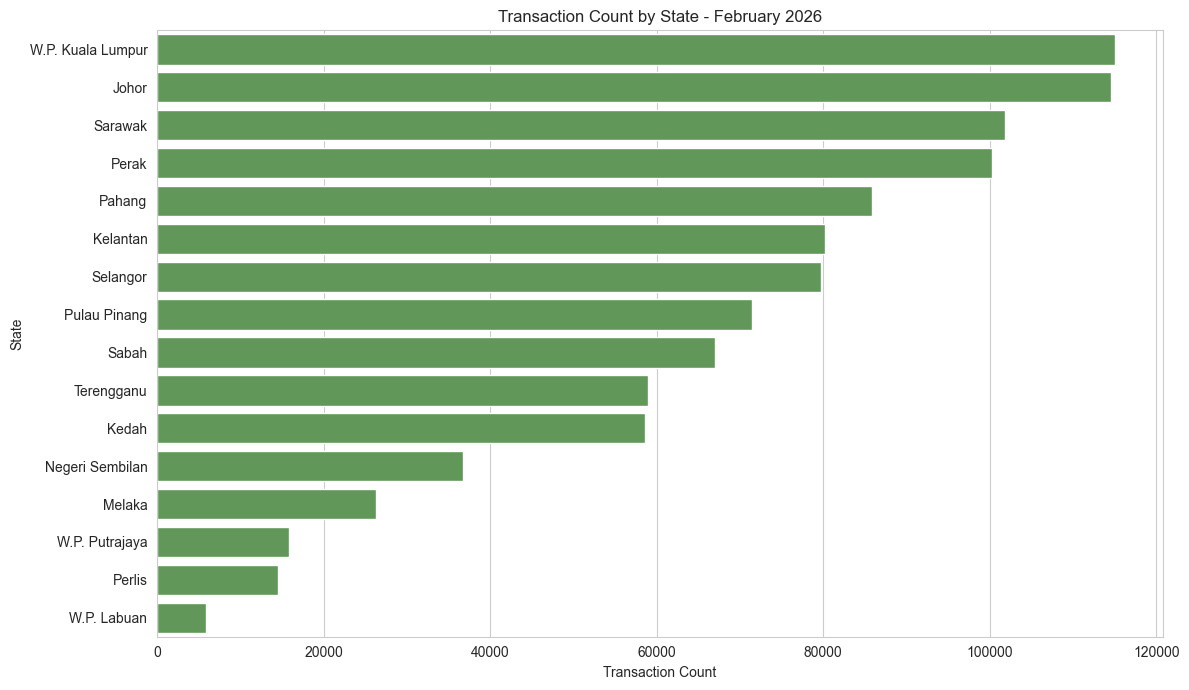

,top_5_states
0,W.P. Kuala Lumpur
1,Johor
2,Sarawak
3,Perak
4,Pahang


,date,state,transaction_count
4,2026-02-03,Johor,3898
9,2026-02-04,Johor,3939
14,2026-02-05,Johor,3884
19,2026-02-06,Johor,3934
24,2026-02-07,Johor,3914
29,2026-02-08,Johor,4277
34,2026-02-09,Johor,18859
39,2026-02-10,Johor,3909
44,2026-02-11,Johor,3996
49,2026-02-12,Johor,19907


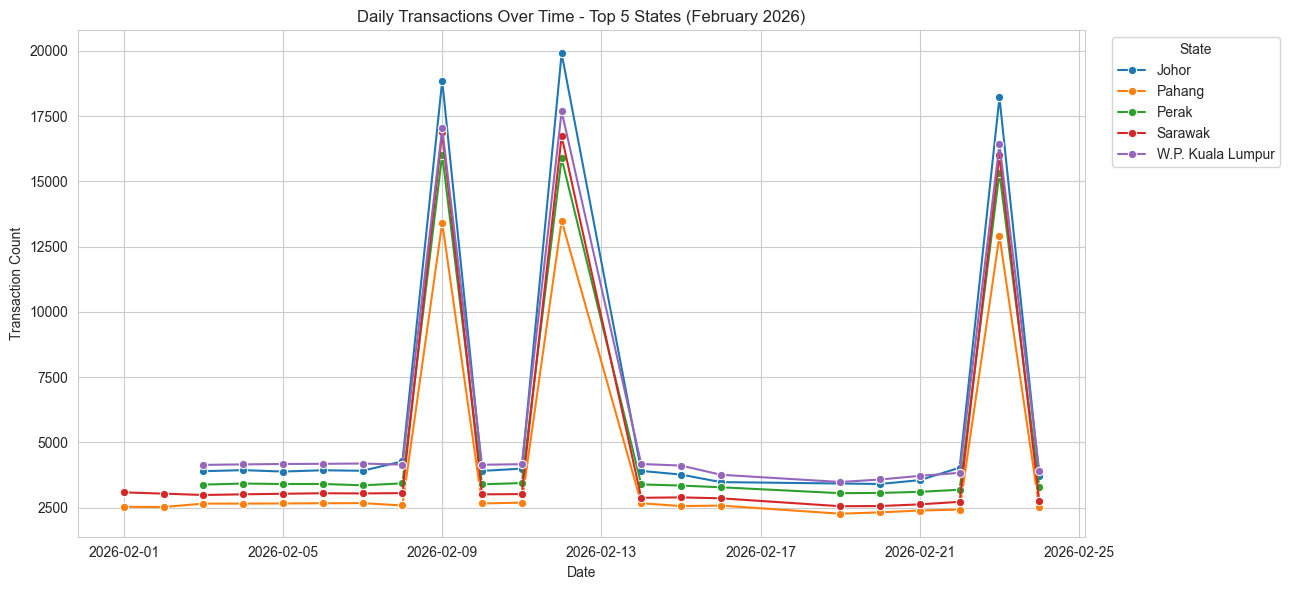

In [ ]:
# Transactions by state (February 2026)
state_counts = (
    feb_2026_df["state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="transaction_count")
)

display(state_counts)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=state_counts,
    x="transaction_count",
    y="state",
    order=state_counts.sort_values(
        "transaction_count", ascending=False)["state"],
    color="#59A14F"
)
ax.set_title("Transaction Count by State - February 2026")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

# Daily transactions over time for top 5 states
top_5_states = state_counts.head(5)["state"].tolist()

daily_top5 = (
    feb_2026_df[feb_2026_df["state"].isin(top_5_states)]
    .groupby(["date", "state"])
    .size()
    .reset_index(name="transaction_count")
    .sort_values(["state", "date"])
)

display(pd.DataFrame({"top_5_states": top_5_states}))
display(daily_top5.head(20))

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=daily_top5,
    x="date",
    y="transaction_count",
    hue="state",
    marker="o"
)
plt.title("Daily Transactions Over Time - Top 5 States (February 2026)")
plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### #3 State spending power (sum of price)

We estimate state-level spending power by summing transaction `price` in February 2026, then rank states by total spend.


,rank,state,total_spending
13,1,W.P. Kuala Lumpur,1438446.20
0,2,Johor,1286731.29
10,3,Sarawak,1265470.10
6,4,Perak,1126754.95
5,5,Pahang,940428.60
11,6,Selangor,940368.12
2,7,Kelantan,890650.21
8,8,Pulau Pinang,798201.83
9,9,Sabah,762368.74
1,10,Kedah,645926.71


,top_state_by_total_spending,total_spending
0,W.P. Kuala Lumpur,1438446.2


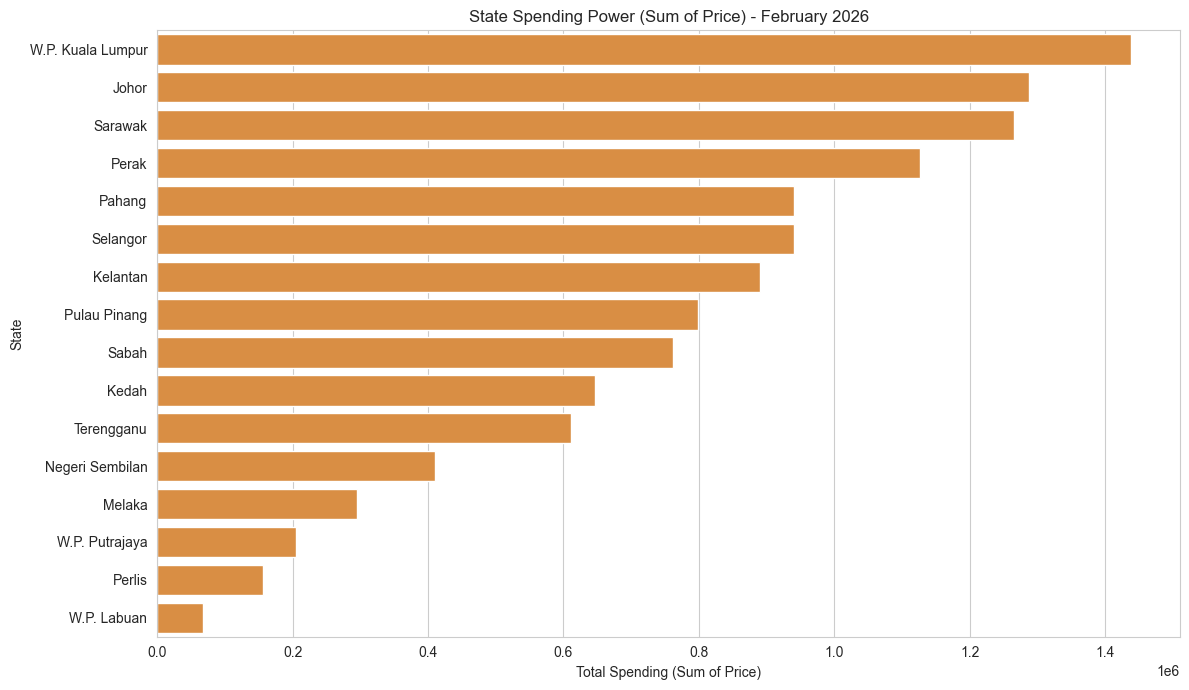

In [4]:
# State spending power by total transaction value (February 2026)
state_spending = (
    feb_2026_df.groupby("state", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "total_spending"})
    .sort_values("total_spending", ascending=False)
)

# Add rank for readability
state_spending["rank"] = range(1, len(state_spending) + 1)
state_spending = state_spending[["rank", "state", "total_spending"]]

display(state_spending)

display(pd.DataFrame([{
    "top_state_by_total_spending": state_spending.iloc[0]["state"],
    "total_spending": state_spending.iloc[0]["total_spending"],
}]))

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=state_spending,
    x="total_spending",
    y="state",
    order=state_spending["state"],
    color="#F28E2B"
)
ax.set_title("State Spending Power (Sum of Price) - February 2026")
ax.set_xlabel("Total Spending (Sum of Price)")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()